This is the initial EDA to explore each dataset and concatenate them together creating a new column to help identify which source file it came from.

In [16]:
#Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

print(os.getcwd())

/Users/stans/eportfolio/eportfolio_Stanley-Southwick/network-anomaly-detector/notebooks


Loading the datasets and combing them togetehr in one

In [17]:
path = Path("/Users/stans/eportfolio/eportfolio_Stanley-Southwick/network-anomaly-detector/data/raw").glob("*.csv") # List all CSV files in the raw data directory

# Loop through the CSV to concatenate them into a single DataFrame
dataframes = []
for csv_file in path:
    df = pd.read_csv(csv_file)
    df['source_file'] = csv_file.name  # Add a column to identify the source file
    dataframes.append(df)
# Concatenate all DataFrames into one
network_data = pd.concat(dataframes, ignore_index=True)



Look at the first few lines of code to get a feel for the data before looking into further details and to check whetehr the new source_file column shows

In [18]:
print(network_data.head())

    Destination Port   Flow Duration   Total Fwd Packets  \
0                 22             166                   1   
1              60148              83                   1   
2                123           99947                   1   
3                123           37017                   1   
4                  0       111161336                 147   

    Total Backward Packets  Total Length of Fwd Packets  \
0                        1                            0   
1                        2                            0   
2                        1                           48   
3                        1                           48   
4                        0                            0   

    Total Length of Bwd Packets   Fwd Packet Length Max  \
0                             0                       0   
1                             0                       0   
2                            48                      48   
3                            48                 

Checking all source files have been added in the source file column

In [19]:
print(network_data['source_file'].unique())

['Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv'
 'Monday-WorkingHours.pcap_ISCX.csv'
 'Friday-WorkingHours-Morning.pcap_ISCX.csv'
 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
 'Tuesday-WorkingHours.pcap_ISCX.csv'
 'Wednesday-workingHours.pcap_ISCX.csv'
 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv']


Simple column and rows analysis as well as each data tyoe and name

In [20]:
print(network_data.shape)
print(network_data.info())

(2830743, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IA

Finding: After EDA it was found that whitespace was affecting my search for columns or stripped the leading whitespace and  Fwd Header Length and Fwd Header Length.1 column were identical and are to be removed in preprocessing stage.

In [21]:
# Remove whitespace in column names
network_data.columns = network_data.columns.str.strip()
# Check whitespace is removed
print(network_data.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [22]:
# Check if 'Fwd Header Length' and 'Fwd Header Length.1' are identical
print(network_data['Fwd Header Length'].equals(network_data['Fwd Header Length.1']))

True


Now analysis for null or duplicate values will be carried out for preprocessing

In [31]:
print(network_data.isnull().sum()[network_data.isnull().sum() > 0])

Flow Bytes/s    1358
dtype: int64


Finding: Flow Bytes/s has 1358 null values (~0.05% of rows). 
Strategy to decide in preprocessing — likely safe to drop or impute given the small number.

Moving on to checking duplciate rows

In [32]:
print(network_data.duplicated().sum())

256479


Finding: 256,479 duplicate rows (~9% of dataset). 
These should be dropped in preprocessing before modelling — keeping them would 
artificially inflate model performance metrics.

Moving onto feature analysis of Label balance and attack types

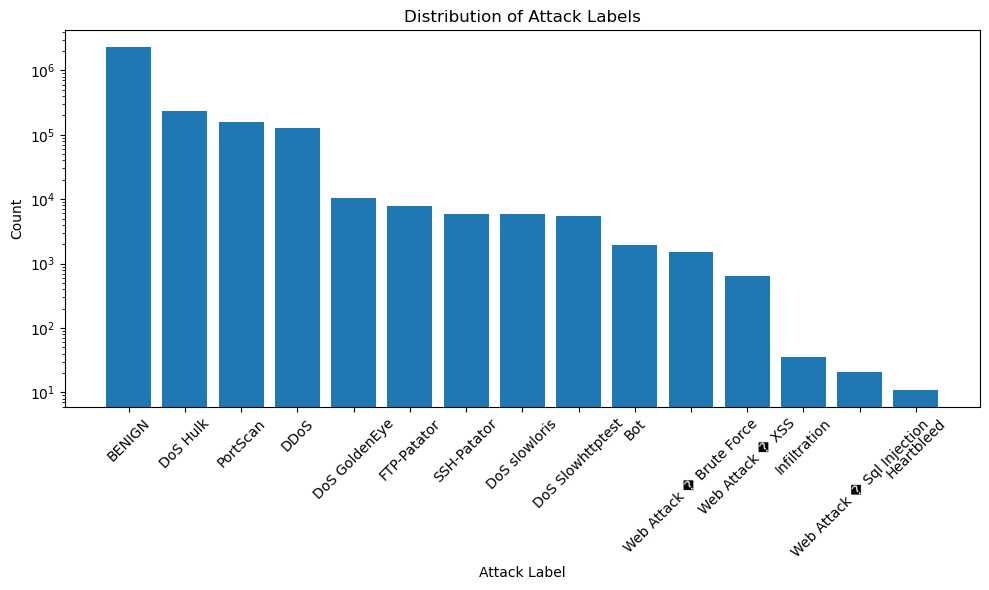

The dataset contains multiple different attacks types as follows: 
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64
[2273097  231073  158930]


In [39]:
# Visualisation of attack label balance
counts = network_data['Label'].value_counts()
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values)
plt.yscale('log')  # Use logarithmic scale for better visibility of smaller classes
plt.title('Distribution of Attack Labels')
plt.xlabel('Attack Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Text summary 
print("The dataset contains multiple different attacks types as follows: \n"
      f"{network_data['Label'].value_counts()}")

print(counts.values[:3])

Class imbalance is sever to Benign. Rare classes are: heartbleed, SQL Injection and Infiltration which need to be oversampled or grouped in preprocessing.

Web attack have character encoding errors which also need to be correted.

Now checking the distribution of attacks on each day from their source files.


In [43]:
distribution_by_day = network_data.groupby('source_file')['Label'].value_counts() 
print(distribution_by_day)

source_file                                                  Label                     
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv             DDoS                          128027
                                                             BENIGN                         97718
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv         PortScan                      158930
                                                             BENIGN                        127537
Friday-WorkingHours-Morning.pcap_ISCX.csv                    BENIGN                        189067
                                                             Bot                             1966
Monday-WorkingHours.pcap_ISCX.csv                            BENIGN                        529918
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv  BENIGN                        288566
                                                             Infiltration                      36
Thursday-WorkingHours-Morning-

Finding: This distribution of attacks by day has shown us a lot. 
- Monday is normal traffic.
- Tuesday - Normal and FTP/ SSh
- Wednesday - All DOS attacks
- Thursday - All web attacks 
- Friday - Morning - Bot attacks
- Friday - Afternoon - DDoS and PortScan

Rare attacks concetrated for heartbleed on Wednesday and Infiltration on Thursday afternoon - something to take note for train/ test splitting 

Moving on to feature analysis